# MAPF Results Visualization

Simple plots showing success rate, runtime, and sum-of-loss for each map.

In [1]:
import glob
import re
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ Ready!")

✅ Ready!


In [2]:
def parse_progress_logs(progress_dir='batch_results/progress_logs'):
    """
    Parse progress logs and extract metrics.
    """
    data = defaultdict(lambda: defaultdict(lambda: {
        'solved': 0,
        'total': 0,
        'runtimes': [],
        'socs': [],
    }))
    
    log_files = glob.glob(f'{progress_dir}/progress_*.log')
    
    for log_file in log_files:
        basename = os.path.basename(log_file)
        match = re.search(r'progress_(.+?)_N(\d+)\.log', basename)
        if not match:
            continue
        
        map_name = match.group(1)
        num_agents = int(match.group(2))
        
        with open(log_file, 'r') as f:
            for line in f:
                line = line.strip()
                
                if line.startswith('✅') or line.startswith('⏱️') or line.startswith('❌'):
                    data[map_name][num_agents]['total'] += 1
                    
                    if 'SOLVED' in line:
                        data[map_name][num_agents]['solved'] += 1
                        
                        runtime_match = re.search(r'runtime=([\d.]+)s', line)
                        if runtime_match:
                            data[map_name][num_agents]['runtimes'].append(float(runtime_match.group(1)))
                        
                        soc_match = re.search(r'soc=(\d+)', line)
                        if soc_match:
                            data[map_name][num_agents]['socs'].append(int(soc_match.group(1)))
    
    return data

print("✅ Functions loaded")

✅ Functions loaded


In [3]:
# Load data
data = parse_progress_logs()
print(f"📊 Loaded {len(data)} maps:")
for map_name in sorted(data.keys()):
    print(f"  - {map_name}")

📊 Loaded 7 maps:
  - brc202d
  - maze-128-128-1
  - pushmap
  - random-32-32-20
  - random-64-64-20
  - small
  - warehouse-20-40-10-2-1


In [4]:
def plot_map_simple(map_name, map_data, save_path=None):
    """
    Create a simple 3-row plot like the example:
    1. Success rate
    2. Runtime
    3. Sum-of-loss (normalized by lower bound)
    """
    agent_counts = sorted(map_data.keys())
    
    # Collect data
    success_rates = []
    mean_runtimes = []
    std_runtimes = []
    mean_socs = []
    std_socs = []
    
    for n in agent_counts:
        metrics = map_data[n]
        
        # Success rate
        success_rate = metrics['solved'] / metrics['total'] if metrics['total'] > 0 else 0
        success_rates.append(success_rate)
        
        # Runtime stats
        if metrics['runtimes']:
            mean_runtimes.append(np.mean(metrics['runtimes']))
            std_runtimes.append(np.std(metrics['runtimes']))
        else:
            mean_runtimes.append(0)
            std_runtimes.append(0)
        
        # SOC stats (normalized by agent count as rough lower bound)
        if metrics['socs']:
            normalized_socs = [soc / n for soc in metrics['socs']]
            mean_socs.append(np.mean(normalized_socs))
            std_socs.append(np.std(normalized_socs))
        else:
            mean_socs.append(0)
            std_socs.append(0)
    
    # Convert to numpy arrays
    agent_counts = np.array(agent_counts)
    success_rates = np.array(success_rates)
    mean_runtimes = np.array(mean_runtimes)
    std_runtimes = np.array(std_runtimes)
    mean_socs = np.array(mean_socs)
    std_socs = np.array(std_socs)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(8, 10))
    fig.suptitle(f'{map_name}', fontsize=14, fontweight='bold', y=0.995)
    
    # Colors
    line_color = '#2196F3'
    fill_alpha = 0.2
    
    # Plot 1: Success Rate
    ax1 = axes[0]
    ax1.plot(agent_counts, success_rates, 'o-', linewidth=2, markersize=6, color=line_color)
    ax1.set_ylabel('success rate', fontsize=11)
    ax1.set_ylim([-0.05, 1.05])
    ax1.grid(True, alpha=0.3)
    ax1.set_xticklabels([])
    
    # Plot 2: Runtime
    ax2 = axes[1]
    ax2.plot(agent_counts, mean_runtimes, 'o-', linewidth=2, markersize=6, color=line_color)
    ax2.fill_between(agent_counts, 
                      mean_runtimes - std_runtimes, 
                      mean_runtimes + std_runtimes,
                      alpha=fill_alpha, color=line_color)
    ax2.set_ylabel('runtime (sec)', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticklabels([])
    
    # Plot 3: Sum-of-Loss / LB
    ax3 = axes[2]
    ax3.plot(agent_counts, mean_socs, 'o-', linewidth=2, markersize=6, color=line_color)
    ax3.fill_between(agent_counts,
                      mean_socs - std_socs,
                      mean_socs + std_socs,
                      alpha=fill_alpha, color=line_color)
    ax3.set_xlabel('number of agents', fontsize=11)
    ax3.set_ylabel('sum-of-cost / agents', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    
    plt.show()

print("✅ Plot function ready")

✅ Plot function ready


## Generate All Plots

Run this cell to create simple plots for all maps


Plotting: brc202d
✅ Saved: batch_results/plots/brc202d_simple.png


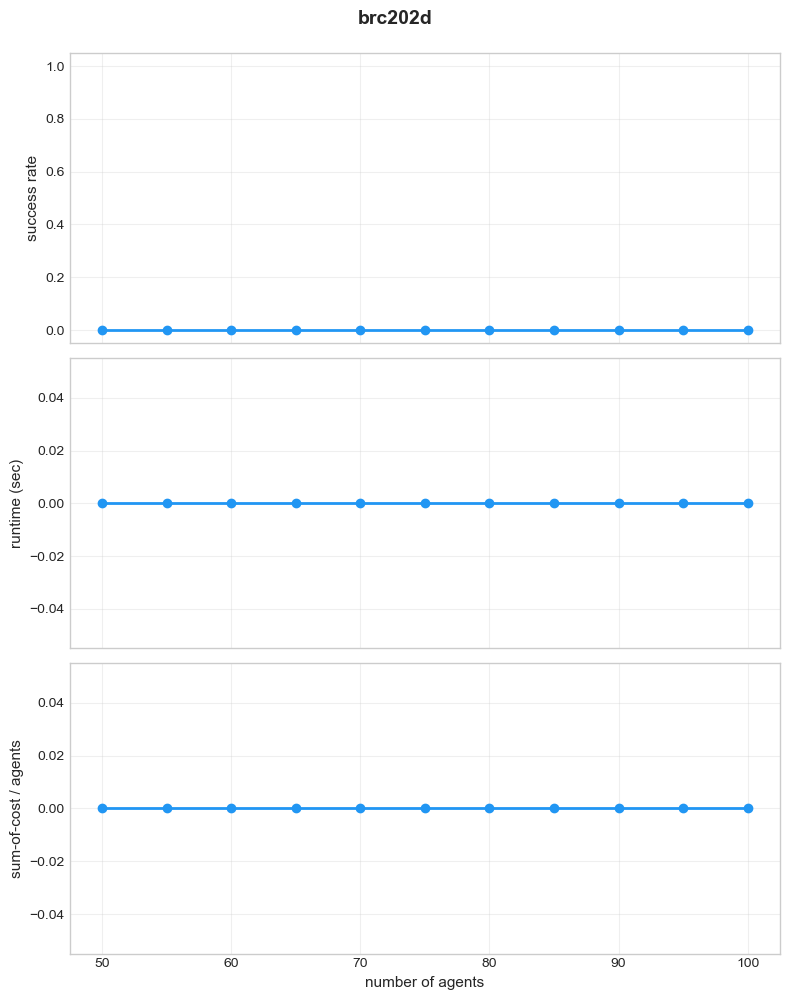


Plotting: maze-128-128-1
✅ Saved: batch_results/plots/maze-128-128-1_simple.png


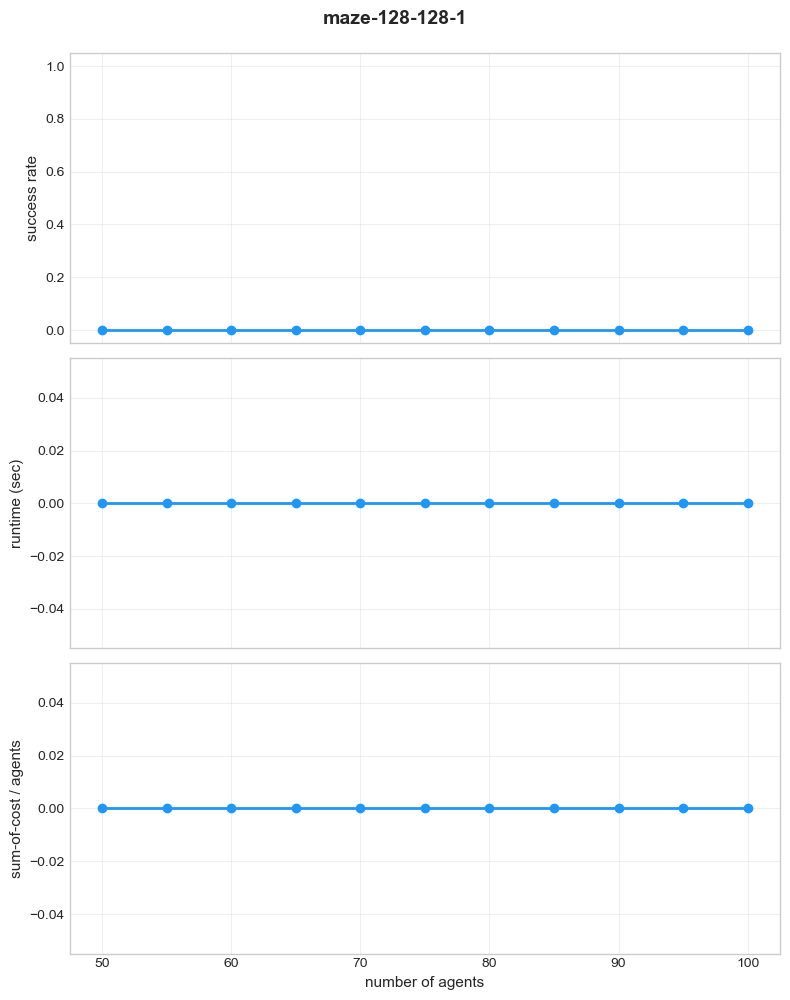


Plotting: pushmap
✅ Saved: batch_results/plots/pushmap_simple.png


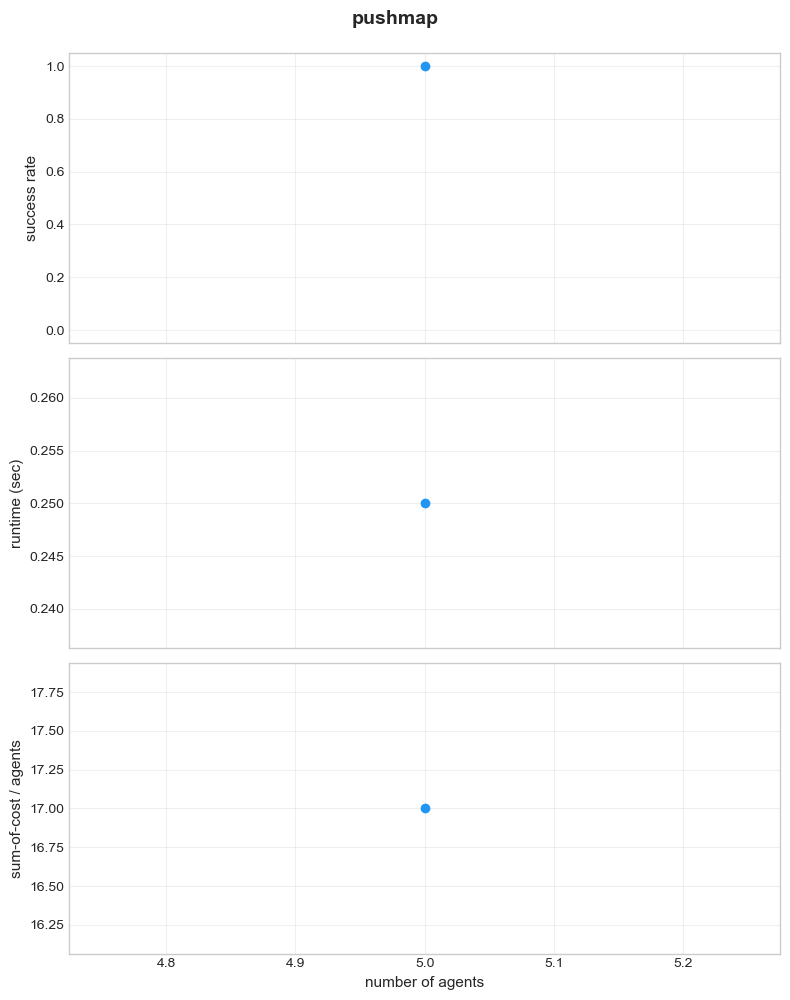


Plotting: random-32-32-20
✅ Saved: batch_results/plots/random-32-32-20_simple.png


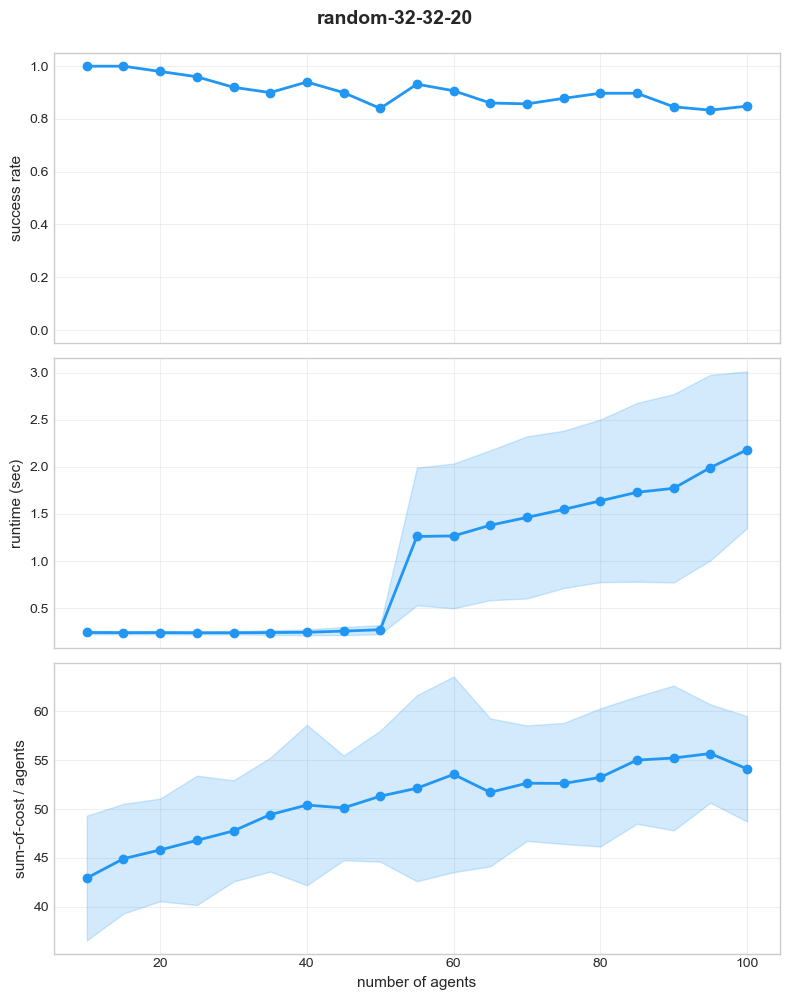


Plotting: random-64-64-20
✅ Saved: batch_results/plots/random-64-64-20_simple.png


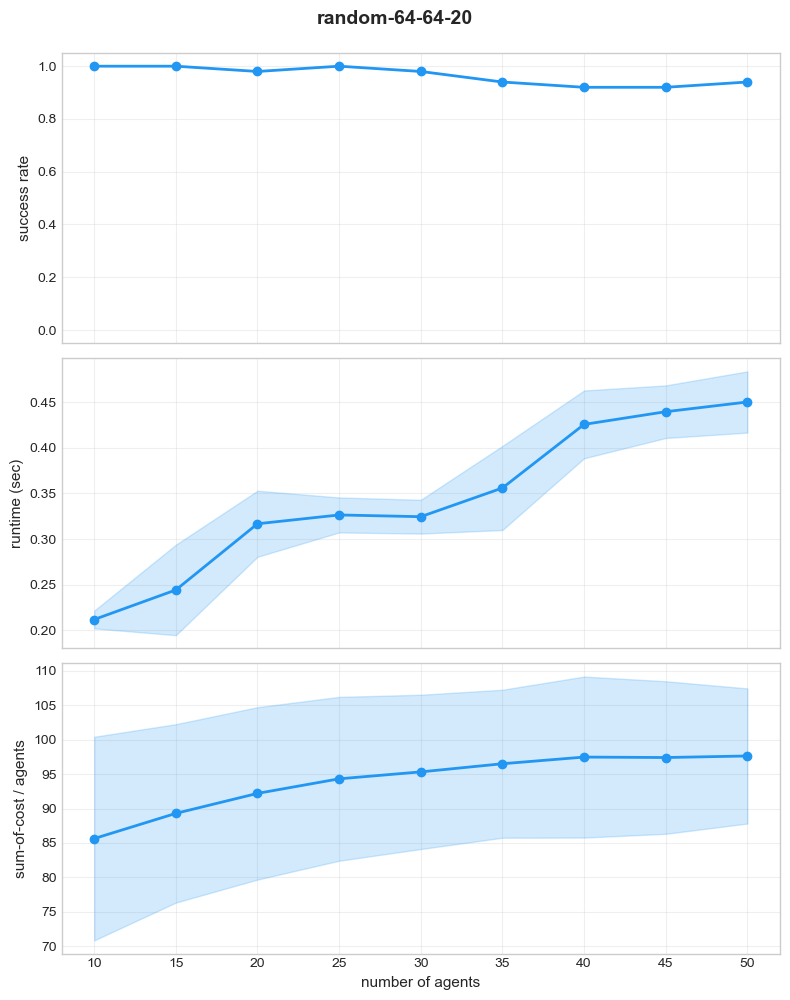


Plotting: small
✅ Saved: batch_results/plots/small_simple.png


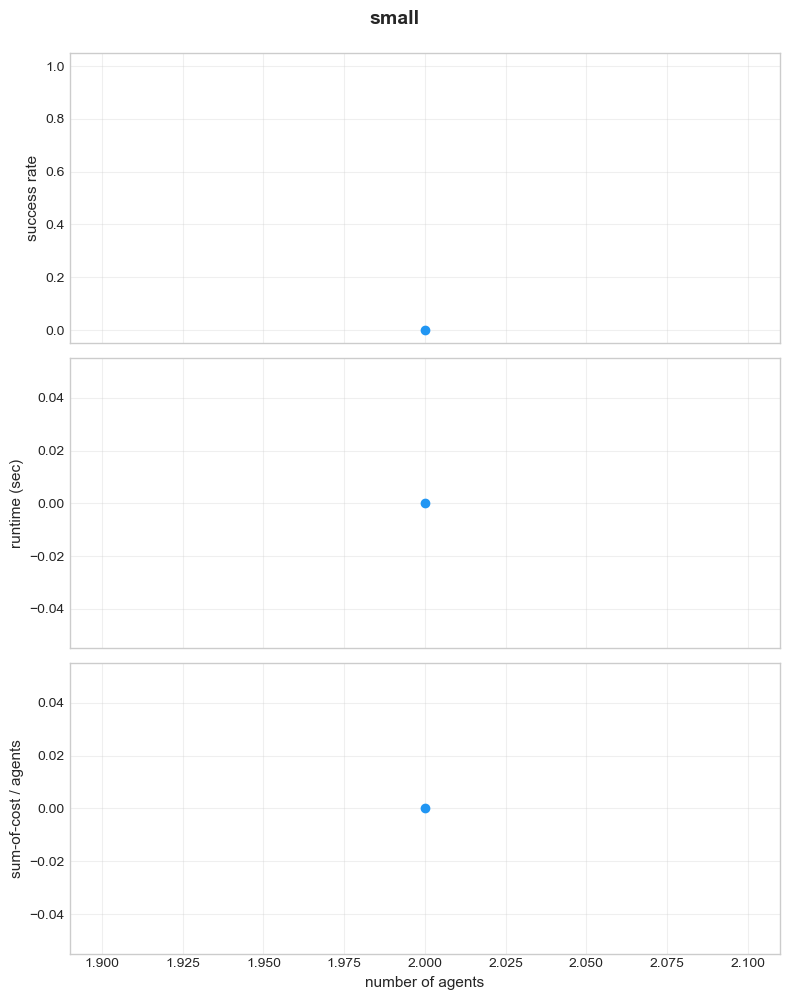


Plotting: warehouse-20-40-10-2-1
✅ Saved: batch_results/plots/warehouse-20-40-10-2-1_simple.png


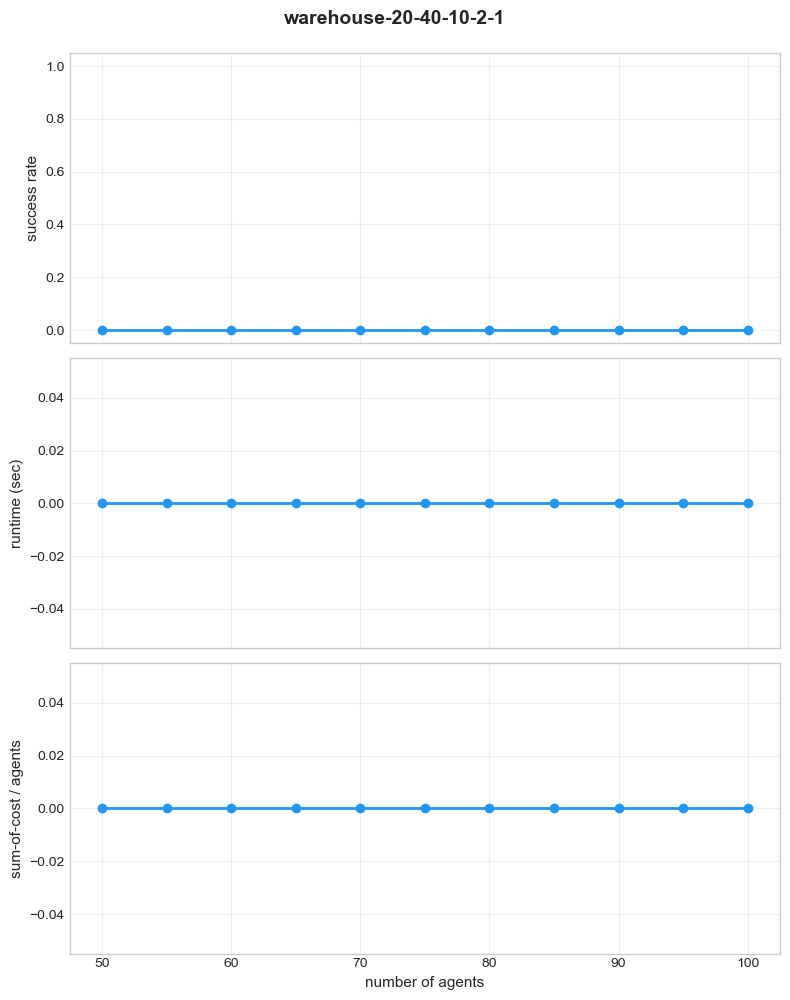


✨ Done! All plots saved to batch_results/plots/


In [5]:
# Create output directory
output_dir = 'batch_results/plots'
os.makedirs(output_dir, exist_ok=True)

# Generate plots for all maps
for map_name in sorted(data.keys()):
    print(f"\nPlotting: {map_name}")
    save_path = f"{output_dir}/{map_name}_simple.png"
    plot_map_simple(map_name, data[map_name], save_path=save_path)

print(f"\n✨ Done! All plots saved to {output_dir}/")

## Plot Single Map (Optional)

Use this to plot just one map interactively

In [6]:
# Example: plot a specific map
# map_name = 'random-32-32-20'  # Change this
# if map_name in data:
#     plot_map_simple(map_name, data[map_name])